### Packages

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


In [57]:
claims_pivot = pd.read_csv("claims_pivot.csv")
codes_df = pd.read_excel("Codes Manual.xlsx")


In [58]:
claims_pivot = pd.read_csv(
    "claims_pivot.csv",
    index_col=0,
    parse_dates=[0]
)

claims_pivot.index.name = "CLAIM_FROM_MONTH"

In [59]:
claims_pivot
claims_pivot_old = claims_pivot.copy()

In [60]:
#remove march-may of 2020
claims_pivot = claims_pivot[~((claims_pivot.index >= '2020-03-01') & (claims_pivot.index <= '2020-05-31'))]
claims_pivot

,0295T,0296T,0297T,0298T,0464T,11100,11101,11102,11103,11104,...,96127,96130,96131,96132,96133,96136,96137,96138,96139,96146
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,10190.0,1047.0,NaN,NaN,NaN,...,146929.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,9802.0,1176.0,NaN,NaN,NaN,...,139342.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,11276.0,1254.0,NaN,NaN,NaN,...,160875.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,11231.0,1243.0,NaN,NaN,NaN,...,162667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,12689.0,1431.0,NaN,NaN,NaN,...,170539.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10805.0,1235.0,1222.0,...,519961.0,33999.0,16529.0,8561.0,4493.0,17752.0,12019.0,9833.0,4186.0,415.0
2024-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10266.0,959.0,1105.0,...,497491.0,33454.0,16023.0,8992.0,4238.0,16747.0,11373.0,10051.0,4099.0,487.0
2024-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11942.0,1400.0,1122.0,...,529734.0,35431.0,16561.0,9451.0,4221.0,17000.0,11737.0,11862.0,4142.0,572.0


### ITS

$Y_tâ€‹=B_0â€‹+B_1â€‹T+B_2â€‹X_tâ€‹+B_3â€‹(X_tâ€‹â‹…T)$

In [61]:
code = "93303"
intervention_month = pd.Timestamp("2021-01-01")

ts = claims_pivot[[code]].reset_index()
ts.columns = ["month", "y"]

# start at first non-zero month so leading missing months are excluded
nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
if len(nonzero_idx) > 0:
    ts = ts.loc[nonzero_idx[0]:].reset_index(drop=True)

ts["y"] = ts["y"].fillna(0)

# time trend
ts["T"] = np.arange(len(ts))

# intervention dummy
ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

# time since intervention
ts["T'"] = 0
if (ts["month"] >= intervention_month).any():
    intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
    ts.loc[ts["month"] >= intervention_month, "T'"] = (
        ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
    )

ts.head(50)

,month,y,T,X_t,T'
0,2018-01-01,25388.0,0,0,0
1,2018-02-01,22642.0,1,0,0
2,2018-03-01,26041.0,2,0,0
3,2018-04-01,24698.0,3,0,0
4,2018-05-01,26248.0,4,0,0
5,2018-06-01,23165.0,5,0,0
6,2018-07-01,24290.0,6,0,0
7,2018-08-01,27872.0,7,0,0
8,2018-09-01,22649.0,8,0,0
9,2018-10-01,27717.0,9,0,0


In [62]:
X = sm.add_constant(ts[["T", "X_t", "T'"]])
y = ts["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     89.19
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.01e-24
Time:                        19:11:51   Log-Likelihood:                -700.95
No. Observations:                  75   AIC:                             1410.
Df Residuals:                      71   BIC:                             1419.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.35e+04    969.560     24.235      0.0

In [63]:
X

,const,T,X_t,T'
0,1.0,0,0,0
1,1.0,1,0,0
2,1.0,2,0,0
3,1.0,3,0,0
4,1.0,4,0,0
...,...,...,...,...
70,1.0,70,1,38
71,1.0,71,1,39
72,1.0,72,1,40
73,1.0,73,1,41


In [64]:
def _trim_to_first_nonzero(ts):
    ts = ts.copy()
    ts["month"] = pd.to_datetime(ts["month"])
    ts["y"] = pd.to_numeric(ts["y"], errors="coerce")

    nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
    if len(nonzero_idx) == 0:
        return ts.iloc[0:0].copy()

    start_idx = nonzero_idx[0]
    return ts.loc[start_idx:].reset_index(drop=True)


def fit_its_single(ts, intervention_month):
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError("Series has no non-zero observations after trimming leading months.")

    # outcome
    ts["y"] = ts["y"].fillna(0)

    # time
    ts["T"] = np.arange(len(ts))

    # intervention indicator
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # post time
    ts["post_time"] = 0
    if (ts["month"] >= intervention_month).any():
        intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
        ts.loc[ts["month"] >= intervention_month, "post_time"] = (
            ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
        )

    # design matrix
    X = sm.add_constant(ts[["T", "X_t", "post_time"]])
    y = ts["y"]

    # fit model
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

    return model

In [65]:
results = []

intervention_month = pd.Timestamp("2021-01-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            # "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            # "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            # "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            # "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            # "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            # "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            # "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            # "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "BIC": model.bic,
            "N_obs": observed
        })

    except Exception as e:
        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 11 months)
Skipping code 27750 due to insufficient data (observed 35 months)
Skipping code 28510 due to insufficient data (observed 34 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping code 75563 due to insufficient data (observed 4 months)
Skipping code 84150 due to insufficient data (observed 16 months)
Skipping code

In [66]:
results_old = []

intervention_month = pd.Timestamp("2021-01-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot_old.columns:

    # build time series
    ts = claims_pivot_old[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results_old.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            # "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            # "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            # "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            # "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            # "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            # "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            # "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            # "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "R_squared": model.rsquared,
            "BIC": model.bic,
            "N_obs": observed
        })

    except Exception as e:
        results_old.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 29 months)
Skipping code 0296T due to insufficient data (observed 36 months)
Skipping code 0297T due to insufficient data (observed 36 months)
Skipping code 0298T due to insufficient data (observed 36 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 19 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 13 months)
Skipping code 27750 due to insufficient data (observed 36 months)
Skipping code 28510 due to insufficient data (observed 35 months)
Skipping code 75557 due to insufficient data (observed 31 months)
Skipping code 75563 due to insufficient data (observed 4 months)
Skipping code 84150 due to insufficient data (observed 16 months)
Skipping code

In [67]:
results_df = pd.DataFrame(results)

# optional sorting
results_df = results_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results_df.columns:
    if pd.api.types.is_numeric_dtype(results_df[col]):
        results_df[col] = results_df[col].apply(smart_format)

#replace nan with 0
results_df = results_df.replace("nan", 0)
results_df = results_df.replace("", 0)
results_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,R_squared,BIC,N_obs
93,93247,continuous cardiac monitoring and detection,0,-857.3050,1792.9227,935.6177,0,1.45E-76,1.11E-94,2.79E-117,0.8021,643.7680,42
90,93243,continuous cardiac monitoring and detection,0,-692.4881,1483.4666,790.9786,0,5.44E-49,5.04E-63,9.47E-81,0.8497,649.0534,42
92,93246,continuous cardiac monitoring and detection,0,-129.9846,300.5532,170.5686,0,6.98E-10,2.82E-14,2.64E-20,0.8313,580.3343,42
54,86140,CRP,140924.5152,2283.8239,38744.8436,-2122.6437,3.64E-245,2.78E-30,4.12E-11,5.60E-13,0.8797,1676.5994,75
94,93248,continuous cardiac monitoring and detection,0,-132.3011,310.3377,178.0366,0,8.35E-07,9.41E-10,9.46E-14,0.8057,597.6316,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,86360,CD4/CD8 subsets,16211.1052,145.8476,-157.5766,-166.7683,2.01E-211,3.53E-06,0.8414,7.93E-06,0.3429,1351.1672,75
19,75574,Cardiac CTA,243.8253,18.2193,6.6046,35.7068,2.36E-32,2.66E-50,0.9389,2.01E-19,0.9317,1051.2840,75
38,85250,Clotting factors (selective use),57.5027,2.3379,-0.5118,1.9625,3.79E-32,1.63E-21,0.9661,0.0005,0.8138,770.2310,75
59,86161,C4,229.2781,8.7042,-0.7943,-5.4249,1.08E-27,9.46E-08,0.9852,0.0025,0.7305,874.8133,75


In [68]:
results_df_old = pd.DataFrame(results_old)

# optional sorting
results_df_old = results_df_old.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results_df_old.columns:
    if pd.api.types.is_numeric_dtype(results_df_old[col]):
        results_df_old[col] = results_df_old[col].apply(smart_format)

#replace nan with 0
results_df_old = results_df_old.replace("nan", 0)
results_df_old = results_df_old.replace("", 0)
results_df_old

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,R_squared,BIC,N_obs
93,93247,continuous cardiac monitoring and detection,0,-857.3050,1792.9227,935.6177,0,1.45E-76,1.11E-94,2.79E-117,0.8021,643.7680,42
90,93243,continuous cardiac monitoring and detection,0,-692.4881,1483.4666,790.9786,0,5.44E-49,5.04E-63,9.47E-81,0.8497,649.0534,42
92,93246,continuous cardiac monitoring and detection,0,-129.9846,300.5532,170.5686,0,6.98E-10,2.82E-14,2.64E-20,0.8313,580.3343,42
94,93248,continuous cardiac monitoring and detection,0,-132.3011,310.3377,178.0366,0,8.35E-07,9.41E-10,9.46E-14,0.8057,597.6316,42
91,93244,continuous cardiac monitoring and detection,0,-65.8891,169.0342,103.1452,0,1.64E-05,4.14E-09,2.38E-14,0.7962,582.8961,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,95924,Combined assessment of the autonomic nervous s...,785.6126,-5.3541,16.7967,10.2635,1.28E-32,0.0687,0.7965,0.0022,0.1545,1008.7196,78
99,94762,"Pulse oximetry (spot / overnight, sometimes us...",4259.3363,-40.0319,110.9260,43.4560,8.40E-54,0.0132,0.7991,0.0157,0.2324,1260.0032,78
25,82542,Prostaglandin D2 (lab-dependent methodology),13965.0916,-119.6735,-286.3581,125.5309,3.56E-122,0.0029,0.8119,0.0044,0.3852,1406.1064,78
79,92625,comprehensive tinnitus assessment,59.8318,-0.4936,2.5242,4.4776,3.01E-22,0.1930,0.9244,0.0297,0.2799,932.7041,76


In [69]:
combined_robust = pd.concat([results_df_old, results_df], axis=1)

In [70]:
combined_robust.to_csv("combined_robust.csv", index=False)

### Plots

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     70.51
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.01e-21
Time:                        19:11:52   Log-Likelihood:                -428.30
No. Observations:                  75   AIC:                             864.6
Df Residuals:                      71   BIC:                             873.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.5740     25.571      2.056      0.0

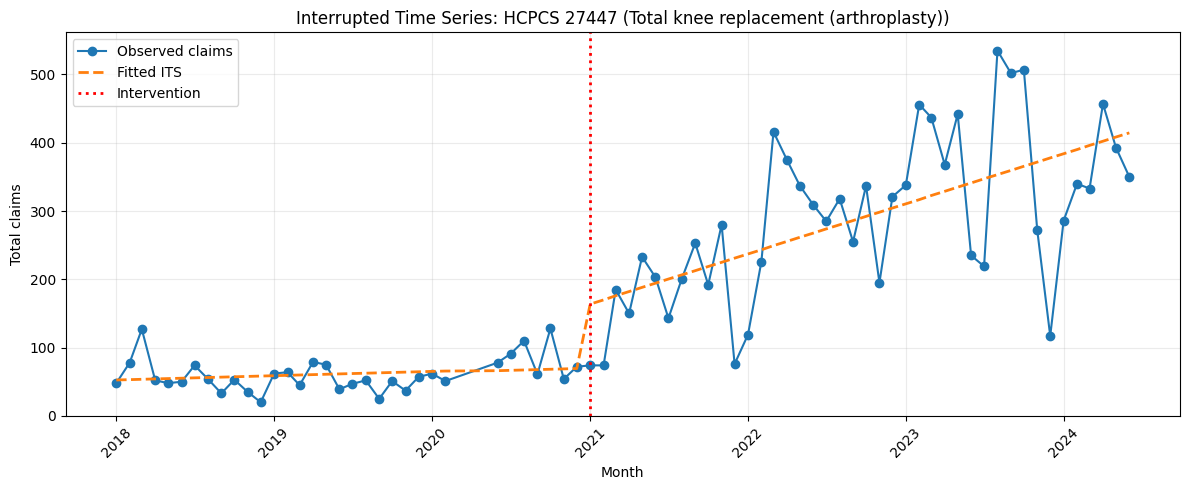

In [71]:
def plot_interrupted_time_series(claims_pivot, code, intervention_month, fill_missing=0, figsize=(12, 5)):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")
    ts["y"] = ts["y"].fillna(fill_missing)

    # time trend
    ts["T"] = np.arange(len(ts))

    # intervention dummy
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # time since intervention
    ts["T'"] = 0
    if (ts["month"] >= intervention_month).any():
        intervention_idx = ts.loc[ts["month"] >= intervention_month, "T"].min()
        ts.loc[ts["month"] >= intervention_month, "T'"] = (
            ts.loc[ts["month"] >= intervention_month, "T"] - intervention_idx + 1
        )

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    model = sm.OLS(y, X).fit()
    ts["y_hat"] = model.predict(X)

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(ts["month"], ts["y"], marker="o", linewidth=1.5, label="Observed claims")
    ax.plot(ts["month"], ts["y_hat"], linestyle="--", linewidth=2, label="Fitted ITS")
    ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total claims")
    y_max = float(np.nanmax(np.r_[ts["y"].to_numpy(dtype=float), ts["y_hat"].to_numpy(dtype=float), [0.0]]))
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))

    title = f"Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


# Example
ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="27447",
    intervention_month=pd.Timestamp("2021-01-01")
)

print(model.summary())

### All Codes -> PowerPoint

Run the next cell to create one slide per HCPCS code with the ITS plot and OLS summary.


In [72]:
from pathlib import Path
import re
import shutil
import tempfile


def _safe_code_label(code):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(code).strip())


CATEGORY_ORDER = [
    "AUTONOMIC TESTING",
    "ADDITIONAL/ADJUNCT AUTONOMIC TESTING",
    "SMALL FIBER NEUROPATHY TESTING",
    "QUANTITATIVE SENSORY TESTING",
    "SUDOMOTOR TESTING",
    "NERVE CONDUCTION STUDIES",
    "AUTONOMIC + CARDIOVASCULAR MONITORING",
    "CORE MAST CELL MEDIATOR TESTING",
    "URINARY MEDIATORS",
    "COMPLEMENT/INFLAMMATORY OVERLAP",
    "CYTOKINE/IMMUNE ACTIVATION",
    "AUTOIMMUNE SCREENING",
    "LYMPHOCYTE SUBSETS/IMMUNE PHENOTYPING",
    "VIRAL REACTIVATION",
    "STANDARD COAGULATION PANEL",
    "FIBRINOLYSIS/CLOT STABILITY",
    "PLATELET FUNCTION/ACTIVATION",
    "HYPERCOAGULABILITY/ENDOTHELIAL INJURY",
    "CARDIAC IMAGING",
    "CARDIAC MONITORING",
    "NEGATIVE CONTROL",
    "TINNITUS",
    "AGGREGATE ANALYSIS",
    "ADDITIONAL",
]
CATEGORY_INDEX = {name: idx for idx, name in enumerate(CATEGORY_ORDER)}


def _normalize_category(category_value):
    if pd.isna(category_value) or not str(category_value).strip():
        return "ADDITIONAL"
    normalized = " ".join(str(category_value).strip().upper().split())
    return normalized if normalized in CATEGORY_INDEX else "ADDITIONAL"


def _code_sort_key(code_value):
    code = str(code_value).strip().upper()
    exact = re.match(r"^(\\d+)([A-Z]*)$", code)
    if exact:
        return (0, int(exact.group(1)), exact.group(2), code)
    prefix = re.match(r"^(\\d+)", code)
    if prefix:
        return (1, int(prefix.group(1)), code)
    return (2, float("inf"), code)


def _order_payloads(payloads):
    return sorted(
        payloads,
        key=lambda item: (
            CATEGORY_INDEX.get(item.get("category", "ADDITIONAL"), CATEGORY_INDEX["ADDITIONAL"]),
            _code_sort_key(item.get("code", "")),
        ),
    )


def _build_metadata_lookup():
    if "codes_df" in globals() and "CODE" in codes_df.columns:
        meta = (
            codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
            .drop_duplicates(subset=["CODE"])
        )
        available_fields = [col for col in ["Description", "Category"] if col in meta.columns]
        if available_fields:
            return meta.set_index("CODE")[available_fields].to_dict(orient="index")
    return {}


def _clean_summary_text(summary_text, drop_notes=True):
    text = str(summary_text)
    text = text.replace(chr(13) + chr(10), chr(10))
    marker = chr(10) + "Notes:" + chr(10)
    if drop_notes and marker in text:
        text = text.split(marker, 1)[0].rstrip()
    return text


def _pick_font_size(summary_text, box_width_pts, box_height_pts):
    # Monospace estimate: char width ~ 0.60 * font_size, line height ~ 1.20 * font_size
    lines = summary_text.splitlines() or [""]
    max_len = max(len(line) for line in lines)
    line_count = len(lines)

    for size in (12, 11, 10, 9, 8, 7, 6):
        max_chars = box_width_pts / (0.60 * size)
        max_lines = box_height_pts / (1.20 * size)
        if max_len <= max_chars and line_count <= max_lines:
            return size

    return 6


def _normalize_code(code_value):
    return str(code_value).strip().upper()


def _sum_codes_series(claims_pivot, target_codes, fill_missing=0):
    lookup = {_normalize_code(col): col for col in claims_pivot.columns}
    present_norm = [code for code in target_codes if code in lookup]
    present_cols = [lookup[code] for code in present_norm]
    missing_norm = [code for code in target_codes if code not in lookup]

    if present_cols:
        series = claims_pivot[present_cols].fillna(fill_missing).sum(axis=1).astype(float)
    else:
        series = pd.Series(np.zeros(len(claims_pivot), dtype=float), index=claims_pivot.index)

    return series, present_norm, missing_norm


def _build_simple_sum_aggregate_payload(
    claims_pivot,
    intervention_month,
    tmp_dir,
    aggregate_code,
    aggregate_title,
    target_codes,
    fill_missing=0,
):
    intervention_month = pd.Timestamp(intervention_month)

    try:
        aggregate_series, present_codes, missing_codes = _sum_codes_series(
            claims_pivot=claims_pivot,
            target_codes=target_codes,
            fill_missing=fill_missing,
        )

        if not present_codes:
            return None, f"{aggregate_title} skipped: none of the selected codes were found in claims_pivot."

        ts_aggregate = pd.DataFrame({"month": claims_pivot.index, "y": aggregate_series.to_numpy(dtype=float)})
        ts_aggregate = _trim_to_first_nonzero(ts_aggregate)
        if ts_aggregate.empty:
            return None, f"{aggregate_title} skipped: aggregate series has no non-zero observations."

        model = fit_its_single(ts_aggregate, intervention_month)

        ts_plot = ts_aggregate.copy()
        ts_plot["T"] = np.arange(len(ts_plot))
        ts_plot["X_t"] = (ts_plot["month"] >= intervention_month).astype(int)
        ts_plot["T'"] = 0
        if (ts_plot["month"] >= intervention_month).any():
            intervention_idx = ts_plot.loc[ts_plot["month"] >= intervention_month, "T"].min()
            ts_plot.loc[ts_plot["month"] >= intervention_month, "T'"] = (
                ts_plot.loc[ts_plot["month"] >= intervention_month, "T"] - intervention_idx + 1
            )
        X_plot = sm.add_constant(ts_plot[["T", "X_t", "T'"]])
        ts_plot["y_hat"] = model.predict(X_plot)

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.plot(ts_plot["month"], ts_plot["y"].to_numpy(dtype=float), marker="o", linewidth=1.5, color="tab:blue", label="Observed claims (sum across selected codes)")
        ax.plot(ts_plot["month"], ts_plot["y_hat"], linestyle="--", linewidth=2, color="tab:orange", label="Fitted ITS")
        ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
        ax.set_xlabel("Month")
        ax.set_ylabel("Total claims")
        y_max = float(
            np.nanmax(
                np.r_[
                    aggregate_series.to_numpy(dtype=float),
                    ts_plot["y_hat"].to_numpy(dtype=float),
                    [0.0],
                ]
            )
        )
        ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))
        ax.set_title(aggregate_title)
        ax.legend()
        ax.grid(alpha=0.25)
        plt.xticks(rotation=45)
        plt.tight_layout()

        plot_path = tmp_dir / f"0000_{_safe_code_label(aggregate_code)}.png"
        fig.savefig(plot_path, dpi=210, bbox_inches="tight", pad_inches=0.01)
        plt.close(fig)

        observed = int(ts_aggregate["y"].notna().sum())
        summary_lines = [
            aggregate_title,
            f"Observed months: {observed}",
            "",
            f"Present codes: {', '.join(present_codes) if present_codes else 'None'}",
            f"Missing codes: {', '.join(missing_codes) if missing_codes else 'None'}",
            "",
            "ITS model below is fitted on aggregate sum across all months.",
            "",
        ]
        summary_text = "\n".join(summary_lines) + _clean_summary_text(model.summary().as_text(), drop_notes=True)

        payload = {
            "code": aggregate_code,
            "category": "AGGREGATE ANALYSIS",
            "observed": observed,
            "title": aggregate_title,
            "plot_path": plot_path,
            "summary_text": summary_text,
        }
        return payload, None

    except Exception as e:
        plt.close("all")
        return None, f"{aggregate_title} failed: {e}"


def _build_aggregate_cardiac_monitoring_payload(claims_pivot, intervention_month, tmp_dir, fill_missing=0):
    # Use the same sum-across-all-months logic as other aggregate analyses.
    combined_codes = ["0295T", "0296T", "0297T", "0298T"] + [str(code) for code in range(93241, 93249)]
    return _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_CARDIAC_MONITORING",
        aggregate_title="Aggregate cardiac monitoring",
        target_codes=combined_codes,
        fill_missing=fill_missing,
    )


def _collect_slide_payloads(
    claims_pivot,
    intervention_month,
    tmp_dir,
    min_observed_months=37,
    fill_missing=0,
):
    meta_lookup = _build_metadata_lookup()

    payloads = []
    skipped = []
    failed = []

    aggregate_payload, aggregate_error = _build_aggregate_cardiac_monitoring_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        fill_missing=fill_missing,
    )
    if aggregate_payload is not None:
        payloads.append(aggregate_payload)
    if aggregate_error is not None:
        failed.append(("AGGREGATE_CARDIAC_MONITORING", aggregate_error))

    biopsy_payload, biopsy_error = _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_BIOPSY_11100_11107",
        aggregate_title="Aggregate biopsy (11100-11107)",
        target_codes=[str(code) for code in range(11100, 11108)],
        fill_missing=fill_missing,
    )
    if biopsy_payload is not None:
        payloads.append(biopsy_payload)
    if biopsy_error is not None:
        failed.append(("AGGREGATE_BIOPSY_11100_11107", biopsy_error))

    ncs_payload, ncs_error = _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_NCS_95907_95913",
        aggregate_title="Aggregate nerve conduction studies (95907-95913)",
        target_codes=[str(code) for code in range(95907, 95914)],
        fill_missing=fill_missing,
    )
    if ncs_payload is not None:
        payloads.append(ncs_payload)
    if ncs_error is not None:
        failed.append(("AGGREGATE_NCS_95907_95913", ncs_error))

    ncs_pair_payload, ncs_pair_error = _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_NCS_95943_95999",
        aggregate_title="Aggregate neurophysiologic/autonomic testing (95943 + 95999)",
        target_codes=["95943", "95999"],
        fill_missing=fill_missing,
    )
    if ncs_pair_payload is not None:
        payloads.append(ncs_pair_payload)
    if ncs_pair_error is not None:
        failed.append(("AGGREGATE_NCS_95943_95999", ncs_pair_error))

    autonomic_payload, autonomic_error = _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_AUTONOMIC_95921_95924",
        aggregate_title="Aggregate autonomic testing (95921-95924)",
        target_codes=[str(code) for code in range(95921, 95925)],
        fill_missing=fill_missing,
    )
    if autonomic_payload is not None:
        payloads.append(autonomic_payload)
    if autonomic_error is not None:
        failed.append(("AGGREGATE_AUTONOMIC_95921_95924", autonomic_error))

    fracture_payload, fracture_error = _build_simple_sum_aggregate_payload(
        claims_pivot=claims_pivot,
        intervention_month=intervention_month,
        tmp_dir=tmp_dir,
        aggregate_code="AGGREGATE_FRACTURES",
        aggregate_title="Aggregate fractures (selected codes)",
        target_codes=["23500", "23600", "25600", "24670", "27500", "27750", "27786", "28470", "21310", "28510", "25605", "27236", "24546", "25606", "27235"],
        fill_missing=fill_missing,
    )
    if fracture_payload is not None:
        payloads.append(fracture_payload)
    if fracture_error is not None:
        failed.append(("AGGREGATE_FRACTURES", fracture_error))

    for idx, code_col in enumerate(claims_pivot.columns, start=1):
        code = str(code_col).strip()
        ts_observed = claims_pivot[[code_col]].reset_index()
        ts_observed.columns = ["month", "y"]
        ts_observed = _trim_to_first_nonzero(ts_observed)
        observed = int(ts_observed["y"].notna().sum())

        if observed < min_observed_months:
            skipped.append((code, observed))
            continue

        try:
            ts, model, fig, ax = plot_interrupted_time_series(
                claims_pivot=claims_pivot,
                code=code_col,
                intervention_month=pd.Timestamp(intervention_month),
                fill_missing=fill_missing,
                figsize=(10, 8),
            )

            plot_path = tmp_dir / f"{idx:04d}_{_safe_code_label(code)}.png"
            fig.savefig(plot_path, dpi=210, bbox_inches="tight", pad_inches=0.01)
            plt.close(fig)

            meta = meta_lookup.get(code, {})
            desc = meta.get("Description")
            category = _normalize_category(meta.get("Category"))
            slide_title = f"HCPCS {code}"
            if pd.notna(desc) and str(desc).strip():
                slide_title += f" - {str(desc).strip()}"
            slide_title += f" ({observed} months of data)"

            payloads.append(
                {
                    "code": code,
                    "category": category,
                    "observed": observed,
                    "title": slide_title,
                    "plot_path": plot_path,
                    "summary_text": _clean_summary_text(model.summary().as_text(), drop_notes=True),
                }
            )

        except Exception as e:
            failed.append((code, str(e)))
            plt.close("all")

    payloads = _order_payloads(payloads)
    return payloads, skipped, failed


def _build_summary_lines(output_path, payloads, skipped, failed, engine):
    lines = [
        f"Output: {output_path}",
        f"Engine: {engine}",
        f"Slides created: {len(payloads)}",
        f"Skipped (insufficient data): {len(skipped)}",
        f"Failed: {len(failed)}",
    ]

    if skipped:
        lines.append("")
        lines.append("First skipped codes:")
        lines.extend([f"- {c} (observed={n})" for c, n in skipped[:20]])

    if failed:
        lines.append("")
        lines.append("First failures:")
        lines.extend([f"- {c}: {msg}" for c, msg in failed[:10]])

    return lines


def _export_with_com(output_path, payloads, summary_lines, intervention_month, min_observed_months):
    import pythoncom
    import win32com.client as win32

    PP_LAYOUT_TITLE = 1
    PP_LAYOUT_BLANK = 12
    MSO_TEXT_ORIENTATION_HORIZONTAL = 1

    # 16:9 widescreen in points
    SLIDE_W = 960
    SLIDE_H = 540

    pythoncom.CoInitialize()
    app = None
    presentation = None

    try:
        app = win32.Dispatch("PowerPoint.Application")
        app.Visible = True
        presentation = app.Presentations.Add()

        try:
            presentation.PageSetup.SlideWidth = SLIDE_W
            presentation.PageSetup.SlideHeight = SLIDE_H
        except Exception:
            pass

        slide_w = float(presentation.PageSetup.SlideWidth)
        slide_h = float(presentation.PageSetup.SlideHeight)

        # Title slide
        title_slide = presentation.Slides.Add(1, PP_LAYOUT_TITLE)
        title_slide.Shapes.Title.TextFrame.TextRange.Text = "Interrupted Time Series by HCPCS Code"
        subtitle = title_slide.Shapes.Placeholders(2).TextFrame.TextRange
        subtitle.Text = (
            f"Intervention month: {pd.Timestamp(intervention_month).date()} | "
            f"Minimum observed months: {min_observed_months}"
        )

        current_category = None
        for item in payloads:
            category = item.get("category", "ADDITIONAL")
            if category != current_category:
                current_category = category
                category_slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_TITLE)
                category_slide.Shapes.Title.TextFrame.TextRange.Text = current_category
                try:
                    category_slide.Shapes.Placeholders(2).TextFrame.TextRange.Text = ""
                except Exception:
                    pass

            slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_BLANK)

            # Fixed two-column layout to match target style
            margin = 14
            gap = 10
            title_h = 38
            content_top = 70
            content_h = slide_h - content_top - margin

            summary_w = slide_w * 0.40
            plot_box_w = slide_w - (margin * 2) - gap - summary_w

            plot_left = margin
            plot_top = content_top
            summary_left = plot_left + plot_box_w + gap

            title_box = slide.Shapes.AddTextbox(
                MSO_TEXT_ORIENTATION_HORIZONTAL,
                margin,
                18,
                slide_w - (margin * 2),
                title_h,
            )
            title_box.TextFrame.TextRange.Text = item["title"]
            title_box.TextFrame.TextRange.Font.Size = 24
            title_box.TextFrame.TextRange.Font.Bold = True

            # Add image at native size, then scale uniformly (preserve aspect ratio)
            pic = slide.Shapes.AddPicture(
                str(item["plot_path"]),
                False,
                True,
                0,
                0,
                -1,
                -1,
            )
            try:
                pic.LockAspectRatio = True
            except Exception:
                pass

            scale = min(plot_box_w / pic.Width, content_h / pic.Height)
            pic.Width = pic.Width * scale
            pic.Height = pic.Height * scale
            pic.Left = plot_left + (plot_box_w - pic.Width) / 2
            pic.Top = plot_top + (content_h - pic.Height) / 2

            summary_box = slide.Shapes.AddTextbox(
                MSO_TEXT_ORIENTATION_HORIZONTAL,
                summary_left,
                content_top,
                summary_w,
                content_h,
            )
            summary_box.TextFrame.MarginLeft = 0
            summary_box.TextFrame.MarginRight = 0
            summary_box.TextFrame.MarginTop = 0
            summary_box.TextFrame.MarginBottom = 0
            summary_box.TextFrame.WordWrap = False
            summary_box.TextFrame.TextRange.Text = item["summary_text"]
            summary_box.TextFrame.TextRange.Font.Name = "Consolas"
            summary_box.TextFrame.TextRange.Font.Size = _pick_font_size(item["summary_text"], summary_w, content_h)

            # Ask PowerPoint to shrink text if still needed.
            try:
                summary_box.TextFrame2.AutoSize = 2
            except Exception:
                pass

        summary_slide = presentation.Slides.Add(presentation.Slides.Count + 1, PP_LAYOUT_BLANK)
        summary_title = summary_slide.Shapes.AddTextbox(MSO_TEXT_ORIENTATION_HORIZONTAL, 24, 18, slide_w - 48, 42)
        summary_title.TextFrame.TextRange.Text = "Build Summary"
        summary_title.TextFrame.TextRange.Font.Size = 26
        summary_title.TextFrame.TextRange.Font.Bold = True

        summary_body = summary_slide.Shapes.AddTextbox(MSO_TEXT_ORIENTATION_HORIZONTAL, 24, 66, slide_w - 48, slide_h - 84)
        summary_body.TextFrame.TextRange.Text = "\n".join(summary_lines)
        summary_body.TextFrame.TextRange.Font.Size = 14

        presentation.SaveAs(str(output_path))

    finally:
        try:
            if presentation is not None:
                presentation.Close()
        finally:
            if app is not None:
                app.Quit()


def _export_with_python_pptx(output_path, payloads, summary_lines, intervention_month, min_observed_months):
    from pptx import Presentation
    from pptx.util import Inches, Pt

    EMU_PER_PT = 12700

    prs = Presentation()
    prs.slide_width = Inches(13.333)
    prs.slide_height = Inches(7.5)

    slide_w = prs.slide_width
    slide_h = prs.slide_height

    # Title slide
    slide = prs.slides.add_slide(prs.slide_layouts[0])
    slide.shapes.title.text = "Interrupted Time Series by HCPCS Code"
    slide.placeholders[1].text = (
        f"Intervention month: {pd.Timestamp(intervention_month).date()} | "
        f"Minimum observed months: {min_observed_months}"
    )

    current_category = None
    for item in payloads:
        category = item.get("category", "ADDITIONAL")
        if category != current_category:
            current_category = category
            category_slide = prs.slides.add_slide(prs.slide_layouts[0])
            category_slide.shapes.title.text = current_category
            try:
                category_slide.placeholders[1].text = ""
            except Exception:
                pass

        s = prs.slides.add_slide(prs.slide_layouts[6])

        # Fixed two-column layout (same visual structure as COM path)
        margin = Inches(0.18)
        gap = Inches(0.12)
        title_h = Inches(0.42)
        content_top = Inches(1.00)
        content_h = slide_h - content_top - margin

        summary_w = int(slide_w * 0.40)
        plot_box_w = slide_w - (margin * 2) - gap - summary_w

        plot_left = margin
        plot_top = content_top
        summary_left = plot_left + plot_box_w + gap

        title_box = s.shapes.add_textbox(margin, Inches(0.15), slide_w - (margin * 2), title_h)
        title_tf = title_box.text_frame
        title_tf.clear()
        p = title_tf.paragraphs[0]
        p.text = item["title"]
        p.font.bold = True
        p.font.size = Pt(24)

        # Add image at native size, then scale uniformly to preserve aspect ratio.
        pic = s.shapes.add_picture(str(item["plot_path"]), 0, 0)
        scale = min(plot_box_w / pic.width, content_h / pic.height)
        pic.width = int(pic.width * scale)
        pic.height = int(pic.height * scale)
        pic.left = int(plot_left + (plot_box_w - pic.width) / 2)
        pic.top = int(plot_top + (content_h - pic.height) / 2)

        summary_box = s.shapes.add_textbox(summary_left, content_top, summary_w, content_h)
        summary_tf = summary_box.text_frame
        summary_tf.clear()
        summary_tf.word_wrap = False
        summary_tf.margin_left = 0
        summary_tf.margin_right = 0
        summary_tf.margin_top = 0
        summary_tf.margin_bottom = 0

        summary_tf.text = item["summary_text"]
        font_size = _pick_font_size(
            item["summary_text"],
            summary_w / EMU_PER_PT,
            content_h / EMU_PER_PT,
        )

        for para in summary_tf.paragraphs:
            para.font.name = "Consolas"
            para.font.size = Pt(font_size)

    # Summary slide
    summary_slide = prs.slides.add_slide(prs.slide_layouts[6])

    title_box = summary_slide.shapes.add_textbox(Inches(0.25), Inches(0.2), Inches(6), Inches(0.5))
    title_tf = title_box.text_frame
    title_tf.text = "Build Summary"
    title_tf.paragraphs[0].font.bold = True
    title_tf.paragraphs[0].font.size = Pt(26)

    body_box = summary_slide.shapes.add_textbox(Inches(0.25), Inches(0.9), Inches(12.8), Inches(6.2))
    body_tf = body_box.text_frame
    body_tf.word_wrap = True
    body_tf.text = "\n".join(summary_lines)
    body_tf.paragraphs[0].font.size = Pt(14)

    prs.save(str(output_path))


def build_all_codes_its_powerpoint(
    claims_pivot,
    intervention_month,
    output_path="its_all_codes_report.pptx",
    min_observed_months=37,
    fill_missing=0,
    engine="auto",  # auto | com | python-pptx
):
    output_path = Path(output_path).resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        output_path.unlink()

    tmp_dir = Path(tempfile.mkdtemp(prefix="its_plots_"))

    try:
        payloads, skipped, failed = _collect_slide_payloads(
            claims_pivot=claims_pivot,
            intervention_month=intervention_month,
            tmp_dir=tmp_dir,
            min_observed_months=min_observed_months,
            fill_missing=fill_missing,
        )

        engines_to_try = []
        if engine == "auto":
            engines_to_try = ["com", "python-pptx"]
        elif engine in {"com", "python-pptx"}:
            engines_to_try = [engine]
        else:
            raise ValueError("engine must be one of: auto, com, python-pptx")

        errors = {}
        used_engine = None

        for candidate in engines_to_try:
            summary_lines = _build_summary_lines(output_path, payloads, skipped, failed, candidate)

            try:
                if candidate == "com":
                    _export_with_com(
                        output_path=output_path,
                        payloads=payloads,
                        summary_lines=summary_lines,
                        intervention_month=intervention_month,
                        min_observed_months=min_observed_months,
                    )
                else:
                    _export_with_python_pptx(
                        output_path=output_path,
                        payloads=payloads,
                        summary_lines=summary_lines,
                        intervention_month=intervention_month,
                        min_observed_months=min_observed_months,
                    )

                used_engine = candidate
                break

            except Exception as e:
                errors[candidate] = str(e)

        if used_engine is None:
            com_msg = errors.get("com", "not attempted")
            pptx_msg = errors.get("python-pptx", "not attempted")
            raise RuntimeError(
                "PowerPoint export failed. "
                f"COM error: {com_msg} | python-pptx error: {pptx_msg}. "
                "If COM fails in headless mode, install python-pptx (pip install python-pptx) "
                "and rerun with engine='python-pptx'."
            )

    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

    return {
        "output_path": str(output_path),
        "engine": used_engine,
        "slides_created": len(payloads),
        "skipped_count": len(skipped),
        "failed_count": len(failed),
        "skipped": skipped,
        "failed": failed,
    }


report = build_all_codes_its_powerpoint(
    claims_pivot=claims_pivot,
    intervention_month=pd.Timestamp("2021-01-01"),
    output_path="its_all_codes_report_robust.pptx",
    min_observed_months=37,
    fill_missing=0,
    engine="auto",
)

print(f"Saved PowerPoint: {report['output_path']}")
print(f"Engine used: {report['engine']}")
print(f"Slides created: {report['slides_created']}")
print(f"Skipped: {report['skipped_count']} | Failed: {report['failed_count']}")
report



Saved PowerPoint: C:\Users\David\MIT Dropbox\David Izrailov\MIT\Academics\Spring\RA\Medicaid\its_all_codes_report_robust.pptx
Engine used: com
Slides created: 139
Skipped: 25 | Failed: 0


{'output_path': 'C:\\Users\\David\\MIT Dropbox\\David Izrailov\\MIT\\Academics\\Spring\\RA\\Medicaid\\its_all_codes_report_robust.pptx',
 'engine': 'com',
 'slides_created': 139,
 'skipped_count': 25,
 'failed_count': 0,
 'skipped': [('0295T', 28),
  ('0296T', 33),
  ('0297T', 33),
  ('0298T', 33),
  ('0464T', 2),
  ('11100', 13),
  ('11101', 12),
  ('21310', 18),
  ('23600', 1),
  ('27500', 11),
  ('27750', 35),
  ('28510', 34),
  ('75557', 31),
  ('75563', 4),
  ('84150', 16),
  ('86051', 30),
  ('86052', 27),
  ('86053', 18),
  ('86362', 30),
  ('86363', 18),
  ('93245', 34),
  ('95999', 35),
  ('96118', 14),
  ('96119', 12),
  ('96120', 12)],
 'failed': []}